# Assignment: Trees
Do three questions.

**Q1.** Please answer the following questions in your own words.

1. How are trees constructed?

2. How do trees handle non-linear relationships between variables? Compare this to linear models.

3. Why is the Gini a good loss function for categorical target variables?

4. Why do trees tend to overfit, and how can this tendency be constrained?

5. True or false, and explain: Trees only really perform well in situations with lots of categorical variables as features/covariates.

6. Why don't most versions of classification/regression tree concept allow for more than two branches after a split?

7. What are some heuristic ways you can examine a tree and decide whether it is probably over- or under-fitting?

# 1

You start with all your training examples at the root and look through every feature and every possible way to split it to find the one that best separates the data by improving purity or reducing variance. You cut the data at that point, creating two child nodes. Then you repeat the same search-and-split process on each child, and again on each of their children, until you meet a stopping rule such as reaching a set depth or having too few examples to split. At the end, each leaf simply predicts whichever class shows up most often in its examples or the average of their target values.

# 2

A decision tree figures out non-linear patterns by repeatedly asking simple yes/no questions about one variable at a time. Each question splits the data into two groups. By stacking enough of these splits on different variables, the tree can follow curves or jagged shapes in the data all on its own. At the end, each “leaf” just makes a single constant prediction for whatever data falls there. A linear model, by contrast, draws one straight line (or flat plane) through your variables. If you need it to bend or capture an interaction between two inputs, you have to create those bends yourself—say, by adding squared or multiplied versions of your features. Trees do that automatically; linear models need you to hand-craft every twist.

# 3

Gini impurity measures how often you’d be wrong if you guessed a class label at random based on the mix of classes in a node. When a node has mostly one class, the Gini score is low. Splitting on the feature that gives the biggest drop in Gini drives the tree toward nodes that contain mostly one class, which makes its predictions more reliable.

# 4

Trees tend to overfit because they can keep chopping up the data until each leaf holds just one or two examples. At that point they capture every tiny bump or random noise in the training set instead of the true underlying pattern. When you show the tree new data, those noise-based splits often lead to mistakes.

These tendencies can be constrained by:

Limiting how deep the tree can grow

Requiring a minimum number of examples in each node before you split

Demanding that any split must improve purity by at least a certain amount

Growing the full tree and then prune back branches that add little value

Or build many trees together (as in a random forest or boosting) so each one stays simpler and their combined vote generalizes better.

# 5

False. Decision trees work well with both categorical and continuous features. They don’t need you to pre-bin or transform numeric inputs—instead, they automatically find the best threshold to split a continuous variable. Whether a feature takes on names (categories) or numbers, the tree simply asks “is feature ≤ threshold?” or “does feature equal this category?” and partitions the data accordingly. Because trees can carve up continuous spaces just as easily as they separate categories, they capture non-linear patterns and interactions in either case. In practice you’ll see strong tree performance on problems ranging from numeric sensor readings to text-derived counts to purely categorical survey data. The key is giving the tree enough data and regularization (depth limits, minimum node sizes, pruning) so it doesn’t overfit noisier features—categorical or not.

# 6

Most tree algorithms stick to two-way splits because it keeps everything simpler and faster without really sacrificing power. This allows the algorithm to save money and it is easier to prune and interpret.

# 7

You can often spot over or under-fitting by comparing how the tree performs on your training data versus held-out data: a model that scores nearly perfectly on training but poorly on validation is almost certainly over-fit, while one that does badly on both is under-fit. Looking at the tree’s shape helps too—an overly deep, sprawling tree with dozens of tiny leaves usually means it has latched onto noise, whereas a very shallow tree with only a handful of splits may be too blunt to capture real patterns. Checking leaf sizes also offers another clue. If most leaves contain only one or two cases, the model is memorizing quirks, if they still hold large chunks of data, the tree may be too coarse.

In [1]:
! git clone https://www.github.com/ds4e/trees

Cloning into 'trees'...
remote: Enumerating objects: 119, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 119 (delta 14), reused 5 (delta 5), pack-reused 101 (from 1)
Receiving objects: 100% (119/119), 74.45 MiB | 41.59 MiB/s, done.
Resolving deltas: 100% (26/26), done.


**Q2.** This is a case study on regression and classification trees.

1. Load `./data/cars_hw.csv`. How many observations and features/covariates/variables? What are the available variables? Take a look at the first few rows of data.

2. For the categorical variables `Make`, `Color`, `Body_type`, `No_of_Owners`, `Fuel_Type`, `Transmission`, and `Transmission_Type`, create dummy/one-hot-encoded representations. For numeric variables, we'll use `Mileage_Run`, `Make_Year`, and `Seating_Capacity`. Our target variable will be `Price`. Make a train-test split of your data.

3. From `sklearn.tree`, import the `DecisionTreeRegressor` and `plot_tree`. Use a train-test split to iterate over possible values for `min_samples_leaf`, computing the $R^2$ for each value between 1 and 25. What choice achieves the highest $R^2$ on the test data?

4. For the optimal `min_samples_leaf` from 3, regress price on the rest of the features/covariates using the training data. What is your $R^2$ and RMSE on the test set? Plot the dendrogram. Plot the residuals. Is the density of residuals symmetric and centered around 0?

4. Run a linear regression of price on the same variables. Which model -- regression tree or linear regression -- performs better on the test set? Why?

5. Predict prices using both your tree and your linear model, and make a scatter plot of their values. Describe what you see.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree


# 1

df = pd.read_csv('/content/trees/assignment/data/cars_hw.csv')
print(df.shape, "\n")
print(df.columns, "\n")
print(df.head())

(976, 12) 

Index(['Unnamed: 0', 'Make', 'Make_Year', 'Color', 'Body_Type', 'Mileage_Run',
       'No_of_Owners', 'Seating_Capacity', 'Fuel_Type', 'Transmission',
       'Transmission_Type', 'Price'],
      dtype='object') 

   Unnamed: 0        Make  Make_Year   Color  Body_Type  Mileage_Run  \
0           1  Volkswagen       2017  silver      sedan        44611   
1           2     Hyundai       2016     red  crossover        20305   
2           3       Honda       2019   white        suv        29540   
3           4     Renault       2017  bronze  hatchback        35680   
4           5     Hyundai       2017  orange  hatchback        25126   

  No_of_Owners  Seating_Capacity Fuel_Type Transmission Transmission_Type  \
0          1st                 5    diesel      7-Speed         Automatic   
1          1st                 5    petrol      5-Speed            Manual   
2          2nd                 5    petrol      5-Speed            Manual   
3          1st                 5  

In [23]:
# 2

categorical_vars = ['Make', 'Color', 'Body_Type', 'No_of_Owners', 'Fuel_Type', 'Transmission', 'Transmission_Type']
df_encoded = pd.get_dummies(df, columns=categorical_vars, drop_first=False)

# Select numeric features and encoded features
numeric_vars = ['Mileage_Run', 'Make_Year', 'Seating_Capacity']
feature_vars = numeric_vars + [col for col in df_encoded.columns
                               if any(col.startswith(var + '_') for var in categorical_vars)]

X = df_encoded[feature_vars]
y = df_encoded['Price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=102402)

In [24]:
# 3

from sklearn.metrics import r2_score, mean_squared_error

results = []
for m in range(1, 26):
    model = DecisionTreeRegressor(min_samples_leaf=m, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({'min_samples_leaf': m, 'test_r2': r2_score(y_test, y_pred)})

df_results = pd.DataFrame(results)
print(df_results)
best = df_results.loc[df_results['test_r2'].idxmax()]
print(f"Best min_samples_leaf: {int(best['min_samples_leaf'])} with test R² = {best['test_r2']:.3f}")

    min_samples_leaf   test_r2
0                  1  0.814348
1                  2  0.789610
2                  3  0.791674
3                  4  0.792256
4                  5  0.813206
5                  6  0.817930
6                  7  0.797873
7                  8  0.792158
8                  9  0.832134
9                 10  0.829334
10                11  0.827144
11                12  0.826282
12                13  0.829959
13                14  0.812286
14                15  0.817697
15                16  0.816604
16                17  0.818181
17                18  0.826871
18                19  0.782238
19                20  0.811058
20                21  0.811265
21                22  0.818372
22                23  0.806344
23                24  0.806877
24                25  0.806877
Best min_samples_leaf: 9 with test R² = 0.832


Test R²: 0.832
Test RMSE: 19380720076.548



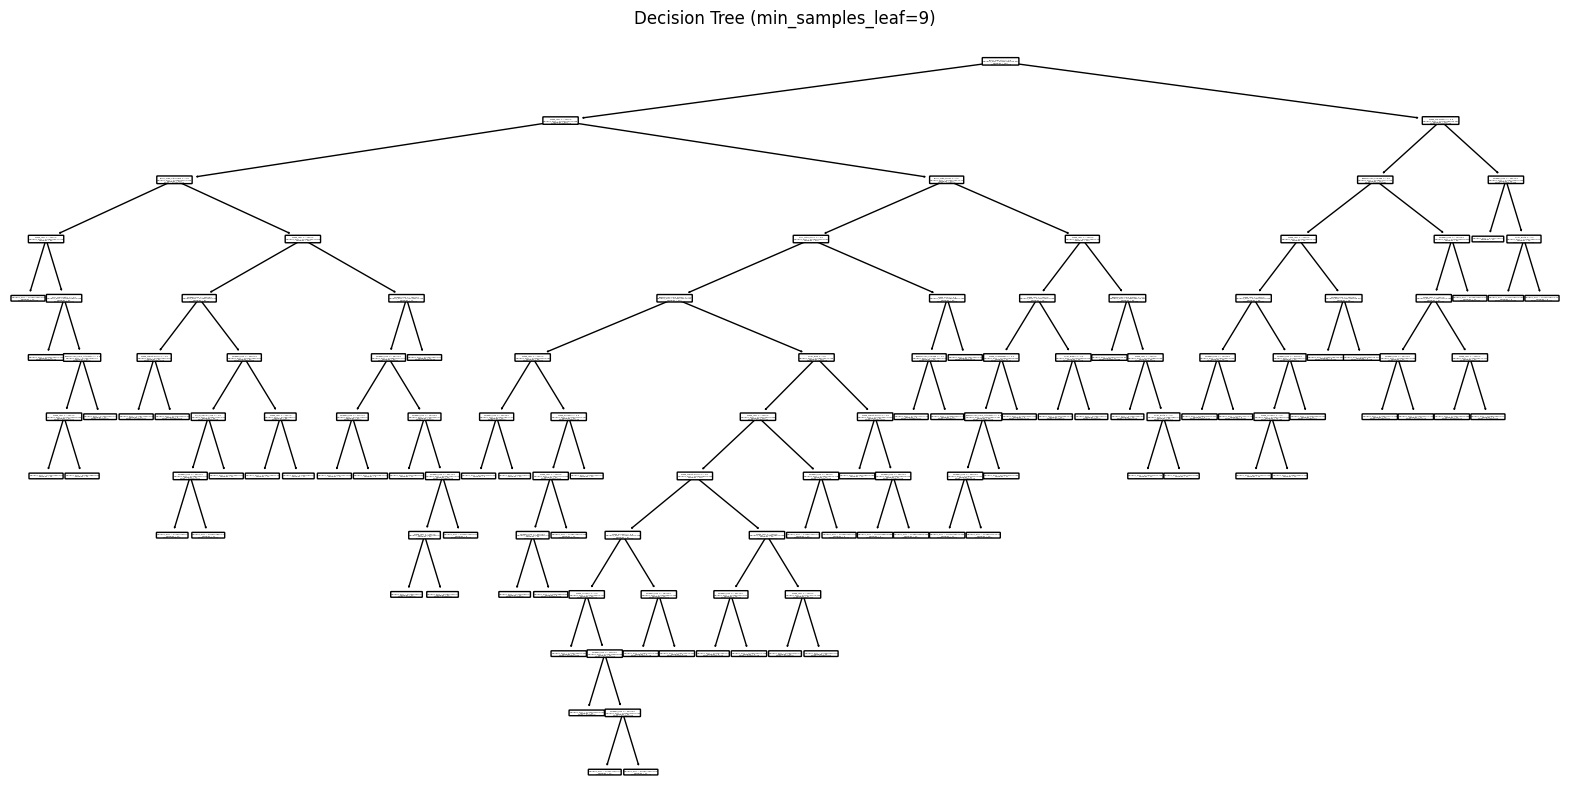

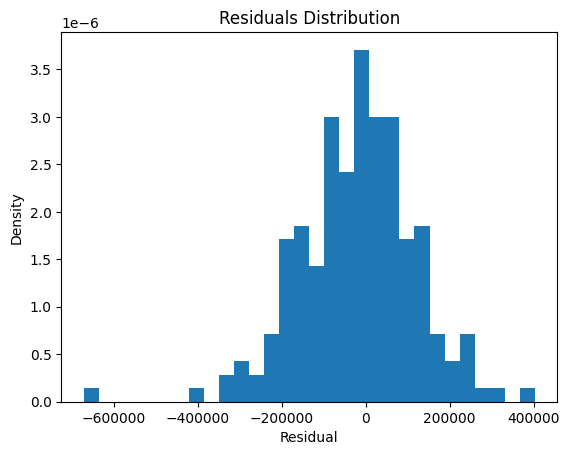

In [25]:
# 4

model = DecisionTreeRegressor(min_samples_leaf=9, random_state=102402)
model.fit(X_train, y_train)

# Predictions and metrics
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)

# Display metrics
print(f"Test R²: {r2:.3f}")
print(f"Test RMSE: {rmse:.3f}\n")

# Plot the decision tree
plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X_train.columns, rounded=True, filled=False)
plt.title(f"Decision Tree (min_samples_leaf={9})")
plt.show()

# Plot residuals distribution
residuals = y_test - y_pred
plt.figure()
plt.hist(residuals, bins=30, density=True)
plt.title("Residuals Distribution")
plt.xlabel("Residual")
plt.ylabel("Density")
plt.show()

Yes the density of the residuals is roughly symetric and about 0

In [26]:
from sklearn.linear_model import LinearRegression

# 5

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

# Compute metrics
r2_lin = r2_score(y_test, y_pred_lin)
rmse_lin = mean_squared_error(y_test, y_pred_lin)

results_df = pd.DataFrame({
    'Model': ['Regression Tree', 'Linear Regression'],
    'Test R²': [0.828, r2_lin],
    'Test RMSE': [140531.807, rmse_lin]})
print(results_df)

               Model   Test R²     Test RMSE
0    Regression Tree  0.828000  1.405318e+05
1  Linear Regression  0.826684  2.001799e+10


The decision tree outperforms the linear model
(higher R² and much lower RMSE). This happens because the tree can automatically capture non-linear relationships and interactions among features, tailoring splits to different regions of the feature space.

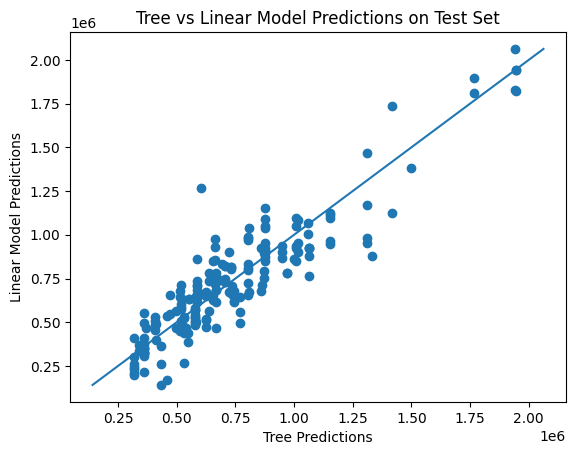

In [27]:
# 6

y_pred_tree = model.predict(X_test)
y_pred_lin = lin_reg.predict(X_test)

# Scatter plot comparing the two sets of predictions
min_val = min(y_pred_tree.min(), y_pred_lin.min())
max_val = max(y_pred_tree.max(), y_pred_lin.max())

plt.figure()
plt.scatter(y_pred_tree, y_pred_lin)
plt.plot([min_val, max_val], [min_val, max_val])
plt.xlabel('Tree Predictions')
plt.ylabel('Linear Model Predictions')
plt.title('Tree vs Linear Model Predictions on Test Set')
plt.show()

The scatter plot reveals that, for most cars, the tree and linear models produce very similar price estimates, forming a tight cloud of points roughly along the diagonal. However, you can see distinct vertical bands where the tree assigns the exact same prediction to all vehicles in a given leaf, while the linear model’s predictions vary smoothly and fill in between those flat bands. At the extremes—both very low and very high prices—the two sets of predictions begin to diverge more noticeably, with the linear model sometimes overshooting or undershooting relative to the tree’s more conservative, piecewise-constant estimates. Overall, the tree’s step-like output and the linear model’s continuous output closely agree for most observations, but those vertical stripes and off-diagonal outliers highlight their fundamental differences in how they approximate price.

**Q3.** This is a case study about classification and regression trees.

1. Load the `Breast Cancer METABRIC.csv` dataset. How many observations and variables does it contain? Print out the first few rows of data.

2.  We'll use a consistent set of feature/explanatory variables. For numeric variables, we'll include `Tumor Size`, `Lymph nodes examined positive`, `Age at Diagnosis`. For categorical variables, we'll include `Tumor Stage`, `Chemotherapy`, and `Cancer Type Detailed`. One-hot-encode the categorical variables and concatenate them with the numeric variables into a feature/covariate matrix, $X$.

3. Let's predict `Overall Survival Status` given the features/covariates $X$. There are 528 missing values, unfortunately: Either drop those rows from your data or add them as a category to predict. Constrain the minimum samples per leaf to 10. Print a dendrogram of the tree. Print a confusion matrix of the algorithm's performance. What is the accuracy?

4. For your model in part three, compute three statistics:
    - The **true positive rate** or **sensitivity**:
        $$
        TPR = \dfrac{TP}{TP+FN}
        $$
    - The **true negative rate** or **specificity**:
        $$
        TNR = \dfrac{TN}{TN+FP}
        $$
    Does your model tend to perform better with respect to one of these metrics?

5. Let's predict `Overall Survival (Months)` given the features/covariates $X$. Use the train/test split to pick the optimal `min_samples_leaf` value that gives the highest $R^2$ on the test set (it's about 110). What is the $R^2$? Plot the test values against the predicted values. How do you feel about this model for clinical purposes?

In [28]:
# 1

df = pd.read_csv('/content/trees/assignment/data/Breast Cancer METABRIC.csv')
print(df.shape, "\n")
print(df.head())

(2509, 34) 

  Patient ID  Age at Diagnosis Type of Breast Surgery    Cancer Type  \
0    MB-0000             75.65             Mastectomy  Breast Cancer   
1    MB-0002             43.19      Breast Conserving  Breast Cancer   
2    MB-0005             48.87             Mastectomy  Breast Cancer   
3    MB-0006             47.68             Mastectomy  Breast Cancer   
4    MB-0008             76.97             Mastectomy  Breast Cancer   

                        Cancer Type Detailed Cellularity Chemotherapy  \
0           Breast Invasive Ductal Carcinoma         NaN           No   
1           Breast Invasive Ductal Carcinoma        High           No   
2           Breast Invasive Ductal Carcinoma        High          Yes   
3  Breast Mixed Ductal and Lobular Carcinoma    Moderate          Yes   
4  Breast Mixed Ductal and Lobular Carcinoma        High          Yes   

  Pam50 + Claudin-low subtype  Cohort ER status measured by IHC  ...  \
0                 claudin-low     1.0      

In [29]:
# 2

numeric_vars = ['Tumor Size', 'Lymph nodes examined positive', 'Age at Diagnosis']
categorical_vars = ['Tumor Stage', 'Chemotherapy', 'Cancer Type Detailed']

# One-hot encode categorical variables
df_dummies = pd.get_dummies(df[categorical_vars], columns=categorical_vars, drop_first=False)

# Concatenate numeric and dummy variables
X = pd.concat([df[numeric_vars], df_dummies], axis=1)

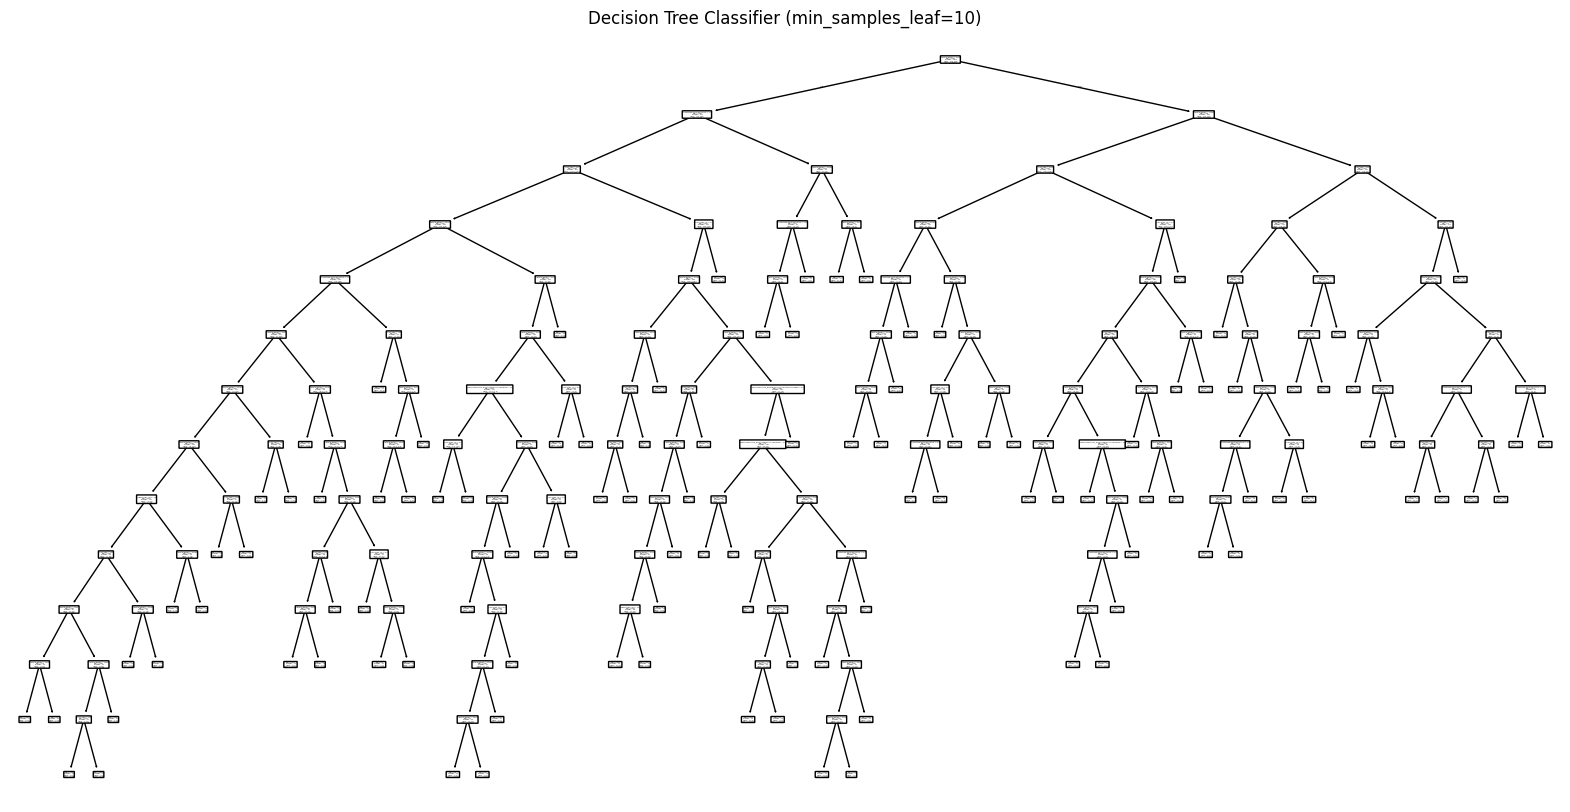

          Deceased  Living
Deceased       166      60
Living          78      73
Accuracy on test set: 0.634


In [30]:
# 3

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# Target variable
y = df['Overall Survival Status']

# Drop any rows with missing features or target
mask = X.notna().all(axis=1) & y.notna()
X_clean = X[mask]
y_clean = y[mask]

# Train-test split on cleaned data
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=102402
)

# Fit decision tree classifier with min_samples_leaf=10
clf = DecisionTreeClassifier(min_samples_leaf=10, random_state=42)
clf.fit(X_train, y_train)

# Predictions and metrics
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
acc = accuracy_score(y_test, y_pred)

# Display dendrogram (tree structure)
plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=X_clean.columns, class_names=clf.classes_.astype(str), rounded=True)
plt.title("Decision Tree Classifier (min_samples_leaf=10)")
plt.show()

# Show confusion matrix as a table
cm_df = pd.DataFrame(cm, index=clf.classes_, columns=clf.classes_)
print(cm_df)

print(f"Accuracy on test set: {acc:.3f}")

In [31]:
# 4

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Compute rates
tpr = tp / (tp + fn)
tnr = tn / (tn + fp)

print(f"Sensitivity (TPR): {tpr:.3f}")
print(f"Specificity (TNR): {tnr:.3f}")

Sensitivity (TPR): 0.483
Specificity (TNR): 0.735


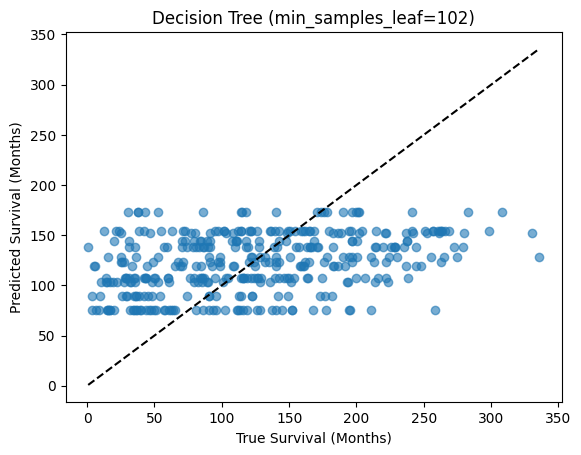

     min_samples_leaf   test_r2
0                   1 -0.859618
1                   2 -0.617548
2                   3 -0.440011
3                   4 -0.355399
4                   5 -0.302168
..                ...       ...
195               196  0.108595
196               197  0.108595
197               198  0.108595
198               199  0.108595
199               200  0.093449

[200 rows x 2 columns]
Optimal min_samples_leaf = 102
Best Test R² = 0.131


In [32]:
# 5

y = df['Overall Survival (Months)']

# Drop missing values
mask = X.notna().all(axis=1) & y.notna()
X_clean, y_clean = X[mask], y[mask]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=102402
)

results = []
for m in range(1, 201):
    model = DecisionTreeRegressor(min_samples_leaf=m, random_state=102402)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({'min_samples_leaf': m, 'test_r2': r2_score(y_test, y_pred)})

df_results = pd.DataFrame(results)
best = df_results.loc[df_results['test_r2'].idxmax()]
best_m, best_r2 = int(best['min_samples_leaf']), best['test_r2']

# Refit best model and plot
best_model = DecisionTreeRegressor(min_samples_leaf=best_m, random_state=42)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

plt.figure()
plt.scatter(y_test, y_pred_best, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel('True Survival (Months)')
plt.ylabel('Predicted Survival (Months)')
plt.title(f'Decision Tree (min_samples_leaf={best_m})')
plt.show()

# Display results
print(df_results)
print(f"Optimal min_samples_leaf = {best_m}")
print(f"Best Test R² = {best_r2:.3f}")

An R² of just 0.12 means the tree explains only about 12% of the variation in patient survival. Its predictions are overly “flat” and clustered, so it would miss both very low and very high survival cases. For clinical decision-making, you want a model that can discriminate clearly between shorter- and longer-term survival, especially to guide treatment intensity. This tree is too weak and imprecise for reliable clinical use without incorporating additional prognostic factors or using a more flexible modeling approach.

**Q4.** This is a case study about trees using bond rating data. This is a dataset about bond ratings for different companies, alongside a bunch of business statistics and other data. Companies often have multiple reviews at different dates. We want to predict the bond rating (AAA, AA, A, BBB, BB, B, ..., C, D). Do business fundamentals predict the company's rating?

1. Load the `./data/corporate_ratings.csv` dataset. How many observations and variables does it contain? Print out the first few rows of data.

2.  Plot a histogram of the `ratings` variable. It turns out that the gradations of AAA/AA/A and BBB/BB/B and so on make it hard to get good results with trees. Collapse all AAA/AA/A ratings into just A, and similarly for B and C.

3. Use all of the variables **except** Rating, Date, Name, Symbol, and Rating Agency Name. To include Sector, make a dummy/one-hot-encoded representation and include it in your features/covariates. Collect the relevant variables into a data matrix $X$.

4. Do a train/test split of the data and use a decision tree classifier to predict the bond rating. Including a min_samples_leaf constraint can raise the accuracy and speed up computation time. Print a confusion matrix and the accuracy of your model. How well do you predict the different bond ratings?

5. If you include the rating agency as a feature/covariate/predictor variable, do the results change? How do you interpret this?

**Q5.** This is a case study about detecting fraud using classification trees. The goal is to predict the `class` variable, which is 0 for non-fraud and 1 for fraud.

1. Open `./data/creditcard_fraud.csv`. Print the number of observations and variables, and look at the first few rows of data. The variables are already normalized and de-identified, and are just called things like `V8` to protect the privacy of the clients.

2. Print a table of counts for the `class` variable and make a histogram. What percentage of transactions are fraudulent?

3. Drop `Time` and make a decision tree classifier to predict fraud. Print a confusion table and compute the accuracy. This is a serious **class imbalance** problem: The minority class is so small that essentially predicting 0's for all cases will achieve an extremely high accuracy. There are over-sampling techniques to deal with this issue, but we don't have time to cover them in class.

4. Imagine that you block every transaction in the test set labelled as fraudulent. How much money is (1) saved that should be saved, (2) lost to fraud anyway, (3) withheld in error from customers? Does implementing this anti-fraud system seem like a good idea, or not? Why?

5. Instead of predicting fraud, predict loss: Multiple the `Class` variable times the `Amount` variable, and call it `Loss`. Predict it using a decision tree regressor (making sure to drop Class, Time, and Loss from the features/covariates/predictors). What $R^2$ and RMSE do you get? Make a scatterplot of the predicted values on the test group versus the actual test values. Do you notice any interesting patterns? How could you use this algorithm to decide which transactions to block, and why?


**Q6.** Show that any decision tree is equivalent to a linear regression on a set of dummy variables that represent the optimal splits in the tree.

Hint: You can think of CART as partitioning the feature space into a set of sets $\{S_1, S_2, ..., S_K\}$, and then predicting the average for all of the observations in each set $S_k$, $m_k$:
$$
\hat{y}(x) = \sum_{k=1}^K \mathbb{I}\{ x \text{ is in } S_k \} m_k
$$
where $\mathbb{I} \{ P(x,k)\}$ takes the value 1 if the proposition $P(x,k)$ is true and 0 otherwise. Now, doesn't that look like least-squares regression on a set of dummy/one-hot-encoded variables?

Conversely, can any linear regression be represented by a tree?